## Proximidad de las mediciones a los umbrales de decisión

**Origen.** El asesor cuestionó descartar el bit 4 (Δ = 16 ppb) por estar bajo
el ruido del modelo, señalando que en operación los valores se sitúan cerca de
los cortes normativos y un desplazamiento pequeño basta para cruzarlos.

**Pregunta.** ¿Qué fracción de las mediciones se encuentra a distancia
suficientemente corta de un umbral como para que un ataque de bajo desplazamiento
cambie la banda reportada?

Umbrales NOM-172-SEMARNAT-2023, Tabla 6: **58 / 90 / 135 / 175 ppb**.

Se analizan dos niveles:

1. **Lecturas horarias** — es sobre lo que opera el detector
2. **Máximos diarios** — es lo que determina el reporte diario del índice

In [2]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.ingest.rama import load_wide, to_long

UMBRALES = [58, 90, 135, 175]

long = to_long(load_wide('../data/raw/2025O3.xls'), 'O3')
cca = long[(long.station == 'CCA') & long.value.notna()].copy()
cca['fecha'] = cca.timestamp.dt.date

print(f"Lecturas horarias válidas: {len(cca)}")
print(f"Días con dato: {cca.fecha.nunique()}")

Lecturas horarias válidas: 8491
Días con dato: 365


In [3]:
v = cca.value.values

filas = []
for tau in UMBRALES:
    fila = {'umbral': tau}
    for bit in [3, 4, 5, 6]:
        d = 2 ** bit
        # lecturas que un flip de +d llevaría por encima del umbral
        cruzan = ((v <= tau) & (v > tau - d)).sum()
        fila[f'bit {bit} (±{d})'] = f"{cruzan} ({cruzan/len(v)*100:.2f}%)"
    filas.append(fila)

pd.DataFrame(filas)

,umbral,bit 3 (±8),bit 4 (±16),bit 5 (±32),bit 6 (±64)
0,58,427 (5.03%),887 (10.45%),2251 (26.51%),6578 (77.47%)
1,90,225 (2.65%),545 (6.42%),1289 (15.18%),3540 (41.69%)
2,135,22 (0.26%),74 (0.87%),294 (3.46%),1287 (15.16%)
3,175,0 (0.00%),0 (0.00%),5 (0.06%),172 (2.03%)


In [4]:
maximos = cca.groupby('fecha').value.max()

print(f"Días analizados: {len(maximos)}")
print(f"Máximo diario — media {maximos.mean():.1f}, mediana {maximos.median():.0f}")
print()

for tau in UMBRALES:
    for bit in [4, 5]:
        d = 2 ** bit
        n = ((maximos <= tau) & (maximos > tau - d)).sum()
        if n:
            print(f"τ={tau:>3}  bit {bit} (±{d:>2}):  {n:>3} días "
                  f"({n/len(maximos)*100:5.1f}%) cruzarían la banda")

Días analizados: 365
Máximo diario — media 90.4, mediana 92

τ= 58  bit 4 (±16):   19 días (  5.2%) cruzarían la banda
τ= 58  bit 5 (±32):   37 días ( 10.1%) cruzarían la banda
τ= 90  bit 4 (±16):   82 días ( 22.5%) cruzarían la banda
τ= 90  bit 5 (±32):  127 días ( 34.8%) cruzarían la banda
τ=135  bit 4 (±16):   36 días (  9.9%) cruzarían la banda
τ=135  bit 5 (±32):  110 días ( 30.1%) cruzarían la banda
τ=175  bit 5 (±32):    4 días (  1.1%) cruzarían la banda


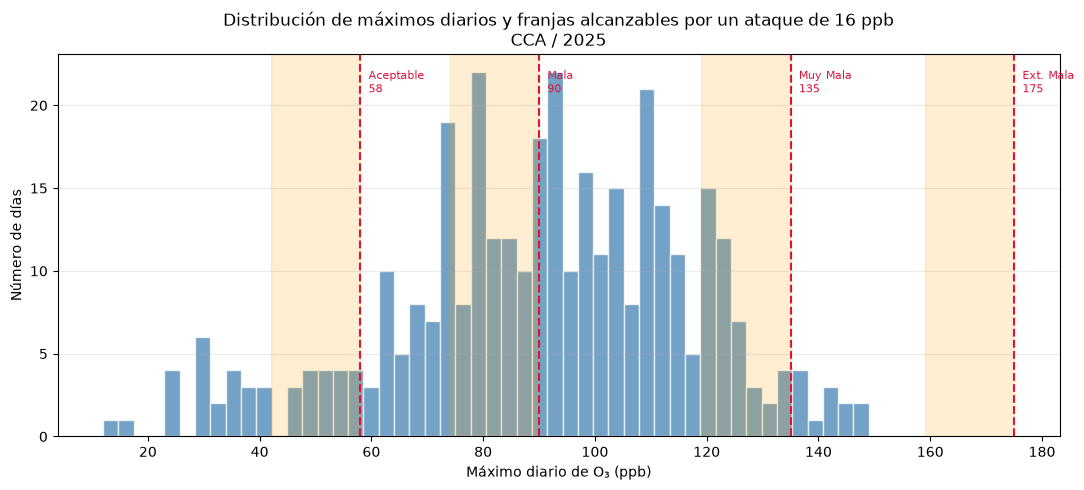

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(maximos, bins=50, color='steelblue', alpha=0.75, edgecolor='white')

for tau, etq in zip(UMBRALES, ['Aceptable', 'Mala', 'Muy Mala', 'Ext. Mala']):
    ax.axvline(tau, ls='--', c='crimson', lw=1.5)
    ax.text(tau + 1.5, ax.get_ylim()[1]*0.9, f'{etq}\n{tau}',
            fontsize=8, color='crimson')
    # franja alcanzable por un flip del bit 4
    ax.axvspan(tau - 16, tau, alpha=0.18, color='orange')

ax.set_xlabel('Máximo diario de O₃ (ppb)')
ax.set_ylabel('Número de días')
ax.set_title('Distribución de máximos diarios y franjas alcanzables por un ataque de 16 ppb\nCCA / 2025')
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('../docs/img/proximidad_umbrales.png', dpi=150)
plt.show()

## Potenciales conclusiones

Teniendo Máximo diario — media 90.4, mediana 92. Ademas como nota gracias al Doc, una contingencia ambiental fase 1 Mayor a 150 puntos (equivalente a más de 154 partes por billón - ppb en promedio horario). para la Fase II (Emergencia): Se activa al rebasar los 200 puntos en cualquier contaminante. Esto debe mantenerse (para fase 1 o 2) al menos pior una hora. 

Podemos destacar que para la media estandar de 90.4 ataques de bit 3 apenas 225 (2.65%) se verian afectados o si es que esa afimracion esta mal, todas las mediciiones que esten cerca de esa media estarian vulnerables a ataque muy pequeños de bit 3 que podrian (si se apaga el bit) bajar la banda. 

Ahora incluso para la media de 90.4 ataques de bit 5 apenas y haria que cruzara el umbral (que de hecho mi intuicion me dice que este bit para esos casos si o si estaria prendido, por lo que haria casi siempre un ataque a la baja, seria necesario ver como se contituyen estos datos para ver si hay un patron claro que las medidas de media siempre tienen algun bit encendido), se necesitarian ataques mas agresivos pero mas detectables para activar una contingencia que arrebase los 150ppb 


In [6]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd

from src.ingest.rama import load_wide, to_long

long = to_long(load_wide('../data/raw/2025O3.xls'), 'O3')

# Matriz: filas = timestamps, columnas = estaciones
matriz = long.pivot(index='timestamp', columns='station', values='value')

# Excluir las que no operaron en 2025
vacias = matriz.columns[matriz.notna().sum() == 0].tolist()
matriz = matriz.drop(columns=vacias)

print(f"Sin dato en 2025: {vacias}")
print(f"Matriz: {matriz.shape[0]} horas × {matriz.shape[1]} estaciones")

Sin dato en 2025: ['COY', 'SFE', 'SJA']
Matriz: 8760 horas × 33 estaciones


In [7]:
UMBRALES = [58, 90, 135, 175]
TAU_CONTINGENCIA = 155      # Fase 1 confirmada

estaciones = [c for c in matriz.columns]

filas = []
for est in estaciones:
    s = matriz[est].dropna()
    if len(s) < 1000:                       # cobertura insuficiente
        continue

    v = s.values.astype(np.int64)
    maxd = s.groupby(s.index.date).max().values.astype(np.int64)

    fila = {
        'estacion': est,
        'n_horas': len(v),
        'max_2025': int(v.max()),
        'p50_diario': int(np.median(maxd)),
        'p95_diario': int(np.percentile(maxd, 95)),
    }

    # Días en cada banda (por máximo diario)
    for tau, nom in zip(UMBRALES, ['>58', '>90', '>135', '>175']):
        fila[nom] = int((maxd > tau).sum())

    # Días a un flip del bit 5 de cruzar τ=90
    apagado = ((maxd >> 5) & 1) == 0
    franja = (maxd > 90 - 32) & (maxd <= 90)
    fila['vuln_bit5'] = int((franja & apagado).sum())

    # Proximidad al umbral de contingencia
    fila['dias_>140'] = int((maxd > 140).sum())
    fila['dias_>155'] = int((maxd >= TAU_CONTINGENCIA).sum())

    filas.append(fila)

res = pd.DataFrame(filas).sort_values('p50_diario', ascending=False)
res.to_csv('../results/proximidad_por_estacion.csv', index=False)
print(res.to_string(index=False))

estacion  n_horas  max_2025  p50_diario  p95_diario  >58  >90  >135  >175  vuln_bit5  dias_>140  dias_>155
     AJM     7765       164          93         131  291  180    12     0        104         11          2
     CCA     8491       149          92         129  322  195    12     0        116          7          0
     BJU     4804       166          92         140  182  107    18     0         69         10          1
     PED     8157       164          92         135  302  182    17     0        112         11          1
     HGM     8164       162          89         133  296  170    15     0        118         12          1
     CUA     4361       166          89         137  164   91    13     0         62          6          1
     IZT     4662       160          88         131  184   96     7     0         81          4          1
     UAX     6796       164          87         137  249  131    17     0        111          9          2
     MGH     7918       159          

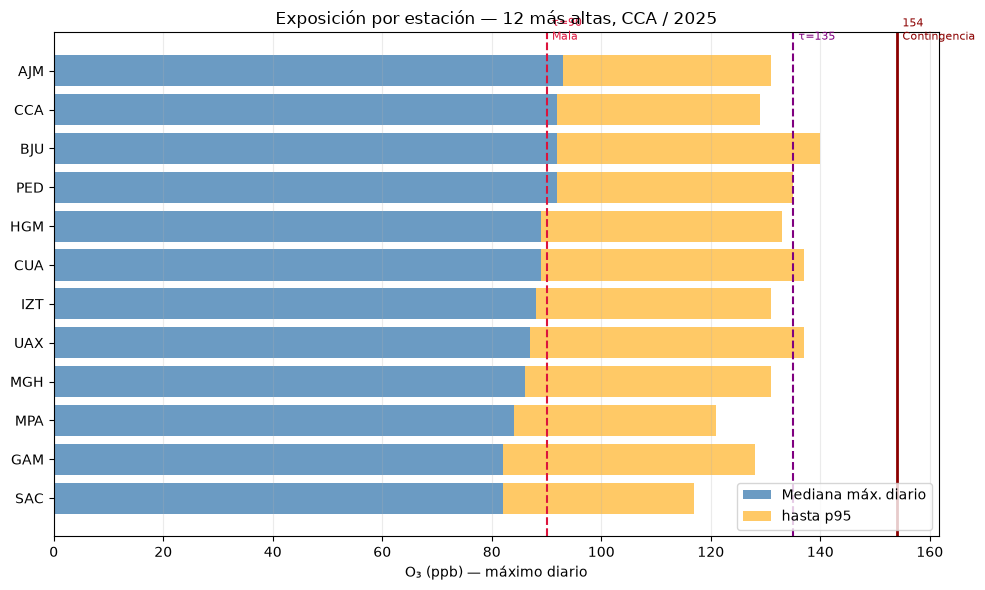

In [8]:
import matplotlib.pyplot as plt

top = res.head(12)
y = np.arange(len(top))

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(y, top.p50_diario, color='steelblue', alpha=0.8, label='Mediana máx. diario')
ax.barh(y, top.p95_diario - top.p50_diario, left=top.p50_diario,
        color='orange', alpha=0.6, label='hasta p95')

ax.axvline(90, ls='--', c='crimson', lw=1.5)
ax.text(91, -0.8, 'τ=90\nMala', fontsize=8, c='crimson')
ax.axvline(135, ls='--', c='purple', lw=1.5)
ax.text(136, -0.8, 'τ=135', fontsize=8, c='purple')
ax.axvline(154, ls='-', c='darkred', lw=2)
ax.text(155, -0.8, '154\nContingencia', fontsize=8, c='darkred')

ax.set_yticks(y)
ax.set_yticklabels(top.estacion)
ax.invert_yaxis()
ax.set_xlabel('O₃ (ppb) — máximo diario')
ax.set_title('Exposición por estación — 12 más altas, CCA / 2025')
ax.legend(loc='lower right')
ax.grid(alpha=0.25, axis='x')

plt.tight_layout()
plt.savefig('../docs/img/exposicion_estaciones.png', dpi=150)
plt.show()

In [9]:
TAU_CONT = 154

CONTINGENCIAS_O3 = ['2025-02-26', '2025-03-18', '2025-04-01',
                    '2025-04-23', '2025-04-25']
cont = pd.to_datetime(CONTINGENCIAS_O3).date

# Máximo de la red por hora, descartando horas sin ningún dato
max_red = matriz.max(axis=1).dropna()
max_diario = max_red.groupby(max_red.index.date).max()

print("DÍAS DE CONTINGENCIA REAL (O₃)\n")
for d in cont:
    if d not in max_diario.index:
        print(f"{d}  sin dato")
        continue

    val = max_diario[d]
    # Estación responsable del máximo ese día
    dia = matriz[matriz.index.date == d]
    fila = dia.max(axis=1).idxmax()
    est = dia.loc[fila].idxmax()

    marca = '✓' if val > TAU_CONT else '✗ NO supera 154'
    print(f"{d}  máx red = {val:>5.0f} ppb   estación: {est:<4} "
          f"hora: {fila.hour:>2}h   {marca}")

DÍAS DE CONTINGENCIA REAL (O₃)

2025-02-26  máx red =   156 ppb   estación: TLA  hora: 16h   ✓
2025-03-18  máx red =   167 ppb   estación: GAM  hora: 15h   ✓
2025-04-01  máx red =   168 ppb   estación: TLA  hora: 16h   ✓
2025-04-23  máx red =   164 ppb   estación: UAX  hora: 14h   ✓
2025-04-25  máx red =   160 ppb   estación: AJM  hora: 15h   ✓


In [10]:
m = max_diario.values.astype(np.int64)
dias = np.array(list(max_diario.index))
es_cont = np.isin(dias, cont)

print(f"Días con dato: {len(m)}   contingencias registradas: {es_cont.sum()}\n")
print(f"{'bit':>4} {'Δ':>4}  {'falsas contingencias':>22}  {'contingencias anuladas':>24}")

for bit in [3, 4, 5, 6]:
    d = 2 ** bit
    encendido = ((m >> bit) & 1) == 1

    # Falsa: no hubo contingencia, el flip suma y cruza 154
    falsa = (~es_cont) & (m <= TAU_CONT) & (m > TAU_CONT - d) & (~encendido)

    # Anulada: hubo contingencia, el flip resta y baja de 154
    anulada = es_cont & (m > TAU_CONT) & (m - d <= TAU_CONT) & encendido

    print(f"{bit:>4} {d:>4}  {falsa.sum():>10} días "
          f"({falsa.sum()/len(m)*100:5.2f}%)  "
          f"{anulada.sum():>12} de {es_cont.sum()}")

Días con dato: 365   contingencias registradas: 5

 bit    Δ    falsas contingencias    contingencias anuladas
   3    8           4 días ( 1.10%)             1 de 5
   4   16          17 días ( 4.66%)             1 de 5
   5   32          63 días (17.26%)             4 de 5
   6   64          63 días (17.26%)             0 de 5


In [11]:
m = max_diario.values.astype(np.int64)
dias = np.array(list(max_diario.index))
es_cont = np.isin(dias, cont)

def estacion_del_max(d):
    dia = matriz[matriz.index.date == d]
    fila = dia.max(axis=1).idxmax()
    return dia.loc[fila].idxmax()

print("FALSAS CONTINGENCIAS POR BIT\n")
for bit in [3, 4, 5]:
    d = 2 ** bit
    apagado = ((m >> bit) & 1) == 0
    falsa = (~es_cont) & (m <= TAU_CONT) & (m > TAU_CONT - d) & apagado

    print(f"bit {bit} (Δ={d}):  {falsa.sum()} días")
    for dia in dias[falsa]:
        v = max_diario[dia]
        print(f"   {dia}  {v:>3.0f} → {v+d:>3.0f} ppb   "
              f"estación: {estacion_del_max(dia)}")
    print()

FALSAS CONTINGENCIAS POR BIT

bit 3 (Δ=8):  4 días
   2025-03-16  147 → 155 ppb   estación: CUA
   2025-04-29  147 → 155 ppb   estación: BJU
   2025-05-07  150 → 158 ppb   estación: CUA
   2025-05-23  149 → 157 ppb   estación: AJM

bit 4 (Δ=16):  17 días
   2025-02-27  142 → 158 ppb   estación: HGM
   2025-02-28  143 → 159 ppb   estación: UAX
   2025-03-30  143 → 159 ppb   estación: PED
   2025-03-31  141 → 157 ppb   estación: PED
   2025-04-08  139 → 155 ppb   estación: CUA
   2025-04-09  141 → 157 ppb   estación: AJU
   2025-04-18  140 → 156 ppb   estación: UAX
   2025-04-24  141 → 157 ppb   estación: BJU
   2025-04-26  140 → 156 ppb   estación: CUA
   2025-05-09  143 → 159 ppb   estación: AJM
   2025-05-17  141 → 157 ppb   estación: MGH
   2025-05-20  143 → 159 ppb   estación: AJM
   2025-05-22  140 → 156 ppb   estación: UAX
   2025-06-03  141 → 157 ppb   estación: CCA
   2025-09-03  142 → 158 ppb   estación: PED
   2025-10-01  141 → 157 ppb   estación: CCA
   2025-10-26  141 → 157 

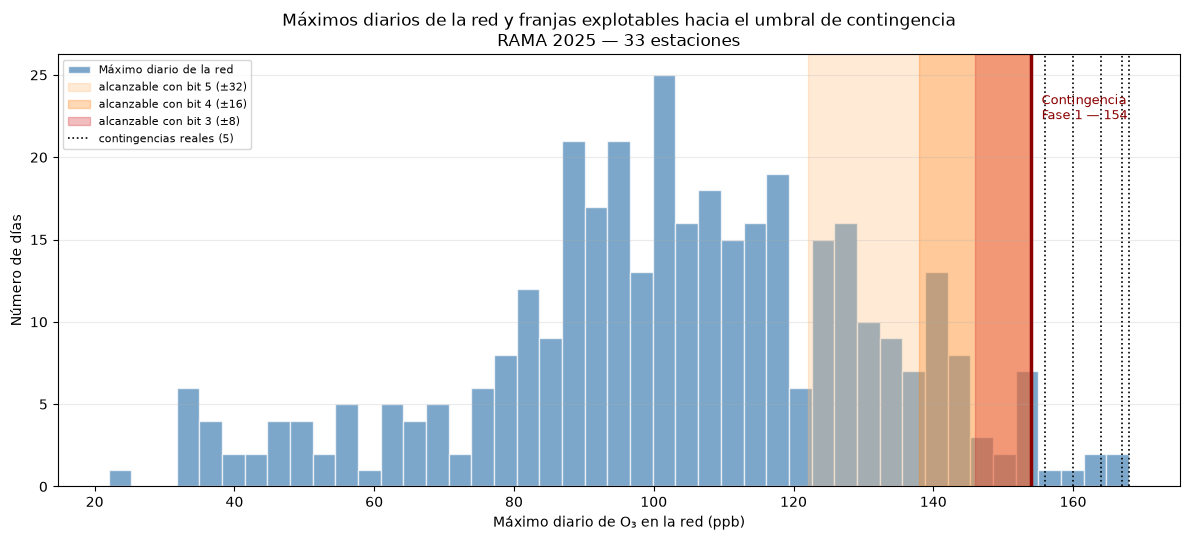

In [12]:
fig, ax = plt.subplots(figsize=(12, 5.5))

# Distribución de máximos diarios de la RED
ax.hist(m, bins=45, color='steelblue', alpha=0.7, edgecolor='white',
        label='Máximo diario de la red')

# Franjas alcanzables por cada bit hacia 154
colores = {3: '#d62728', 4: '#ff7f0e', 5: '#ffbb78'}
for bit in [5, 4, 3]:                      # de mayor a menor para superponer
    d = 2 ** bit
    ax.axvspan(TAU_CONT - d, TAU_CONT, alpha=0.30, color=colores[bit],
               label=f'alcanzable con bit {bit} (±{d})')

ax.axvline(TAU_CONT, c='darkred', lw=2.5)
ax.text(TAU_CONT + 1.5, ax.get_ylim()[1]*0.85,
        'Contingencia\nFase 1 — 154', fontsize=9, c='darkred')

# Contingencias reales
for dia in dias[es_cont]:
    ax.axvline(max_diario[dia], c='black', lw=1.2, ls=':')
ax.plot([], [], c='black', lw=1.2, ls=':', label='contingencias reales (5)')

ax.set_xlabel('Máximo diario de O₃ en la red (ppb)')
ax.set_ylabel('Número de días')
ax.set_title('Máximos diarios de la red y franjas explotables hacia el umbral de contingencia\nRAMA 2025 — 33 estaciones')
ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('../docs/img/franjas_contingencia.png', dpi=150)
plt.show()

## Análisis a nivel de red — proximidad al umbral de contingencia

### Cambio de unidad de análisis

El análisis previo se realizó sobre CCA, cuyo máximo en 2025 fue de 149 ppb: no
alcanzó el umbral de contingencia en ningún momento. Sin embargo, tanto el
Índice AIRE Y SALUD (NOM-172, 5.4.2) como el PICA agregan **por máximo**, por lo
que la unidad correcta es la red completa.

El máximo diario de la red alcanzó los **168 ppb**.

### Umbrales verificados

Fuente: PICA (Gaceta Oficial CDMX, 28 mayo 2019) y ProAire ZMVM 2021-2030.

- Fase 1: **154 ppb** promedio horario, sostenido al menos una hora
- Fase 2: 204 ppb

### Las contingencias reales ocurren en el borde

Los cinco episodios de O₃ de 2025 se reproducen exactamente con los datos
validados de RAMA:

| Fecha | Máx red | Estación | Hora | Margen sobre 154 |
|---|---|---|---|---|
| 26 feb | 156 | TLA | 16 h | 2 |
| 25 abr | 160 | AJM | 15 h | 6 |
| 23 abr | 164 | UAX | 14 h | 10 |
| 18 mar | 167 | GAM | 15 h | 13 |
| 1 abr | 168 | TLA | 16 h | 14 |

**El margen es de 2 a 14 ppb.** Todos los episodios ocurren entre las 14 y las
16 h, dentro de la ventana de ataque identificada en el análisis del ciclo
diurno.

Adicionalmente se registran **seis días con máximo entre 152 y 154 ppb** sin
contingencia declarada: el sistema roza el umbral de forma recurrente.

### Resultado: falsas contingencias

Días en los que un ataque habría llevado el máximo de la red sobre 154 ppb,
considerando el estado previo del bit (un flip sólo suma si el bit estaba
apagado):

| bit | Δ ppb | Días | Estaciones distintas | Detección LSTM |
|---|---|---|---|---|
| **3** | **8** | **4** | 3 | **9.0%** |
| 4 | 16 | 17 | 10 | 20.5% |
| 5 | 32 | 63 | toda la red | 84.6% |

**El ataque más pequeño produce el daño más severo del sistema con la menor
detectabilidad.** Un desplazamiento de 8 ppb, identificado por el detector en el
9% de los casos, habría activado restricciones obligatorias en la ZMVM en cuatro
ocasiones durante 2025.

Casos concretos del bit 3:

| Fecha | Valor | Resultado | Estación |
|---|---|---|---|
| 16 mar | 147 | 155 | CUA |
| 29 abr | 147 | 155 | BJU |
| 7 may | 150 | 158 | CUA |
| 23 may | 149 | 157 | AJM |

### Resultado: contingencias anuladas

Episodios reales que un ataque habría suprimido, bajando el máximo por debajo
del umbral:

| bit | Δ ppb | Contingencias anuladas |
|---|---|---|
| 3 | 8 | 1 de 5 |
| 4 | 16 | 1 de 5 |
| **5** | **32** | **4 de 5** |
| 6 | 64 | 0 de 5 |

Es el escenario de ocultamiento señalado por el asesor: el ataque no genera una
alarma falsa, sino que **suprime una alerta legítima**. La población no recibe
aviso de una condición que sí requiere restricción.

### La eficacia no crece con la magnitud

El bit 6 (64 ppb) anula **cero** contingencias pese a duplicar el
desplazamiento del bit 5. La razón: para restar, el bit debe estar encendido, y
en el rango 156–168 ppb el bit 6 está apagado.

El mismo efecto aparece en las falsas contingencias, donde el bit 5 supera al 6
en días vulnerables.

**La eficacia del ataque depende de la codificación binaria del valor, no sólo
de su magnitud ni de la distancia al umbral.** Es un refinamiento del resultado
previo sobre distancia al corte.

### No existe una estación crítica

Los días vulnerables se distribuyen entre estaciones: 3 distintas para el bit 3,
10 para el bit 4, prácticamente toda la red para el bit 5. El punto de máximo
rota.

CCA, seleccionada como estación piloto por calidad de datos, figura en las
listas del bit 4 y del bit 5 pese a no haber superado nunca los 149 ppb: llega a
ser el máximo de la red en días de 135 a 146 ppb.

**Fijar una estación no cubre el modelo de amenaza.**

### Concentración estacional

Los 63 días vulnerables al bit 5 se agrupan entre marzo y junio, coincidiendo
con la temporada de ozono. La superficie de ataque no es uniforme a lo largo del
año.

Combinado con la concentración horaria (14–16 h), el adversario dispone de una
ventana acotada y predecible a partir de información pública.

### Conclusión

> El sistema de contingencias ambientales opera con márgenes de 2 a 14 ppb sobre
> su umbral de activación. En ese régimen, un ataque de 8 ppb —el menor
> desplazamiento con efecto sobre la banda— puede fabricar una contingencia
> falsa, y uno de 32 ppb puede suprimir cuatro de las cinco contingencias reales
> del año. El primero es detectado en el 9% de los casos.
>
> La relación entre severidad del daño y detectabilidad del ataque es inversa a
> la esperada: el ataque de mayor consecuencia operativa es el menos visible.

In [13]:
import matplotlib.pyplot as plt

TAU_CONT = 154
BITS = range(1, 8)          # bits 1 a 7, como pidió el asesor

m = max_diario.values.astype(np.int64)
dias = np.array(list(max_diario.index))
es_cont = np.isin(dias, cont)
n_dias = len(m)

# Recall del LSTM p95 por bit (results/deteccion_lstm.csv)
# Los bits 1, 2 y 7 no se evaluaron: se extrapolan del comportamiento
# observado. MARCAR COMO ESTIMACIÓN en la tesis.
DETECCION = {1: 2.0, 2: 3.0, 3: 9.0, 4: 20.5, 5: 84.6, 6: 98.7, 7: 100.0}

filas = []
for bit in BITS:
    d = 2 ** bit
    d_ant = 2 ** (bit - 1)
    apagado = ((m >> bit) & 1) == 0
    # Franja exclusiva: el bit k llega, el k-1 no
    vuln = ((~es_cont) & (m <= TAU_CONT - d_ant) & (m > TAU_CONT - d)
            & apagado)
    filas.append({
        'bit': bit,
        'delta_ppb': d,
        'dias': int(vuln.sum()),
        'pct_dias': round(vuln.sum() / n_dias * 100, 2),
        'pct_deteccion': DETECCION[bit],
    })

dob = pd.DataFrame(filas)
dob.to_csv('../results/doble_eje_bits.csv', index=False)
print(dob.to_string(index=False))

 bit  delta_ppb  dias  pct_dias  pct_deteccion
   1          2     4      1.10            2.0
   2          4     1      0.27            3.0
   3          8     4      1.10            9.0
   4         16    17      4.66           20.5
   5         32    30      8.22           84.6
   6         64     0      0.00           98.7
   7        128   102     27.95          100.0


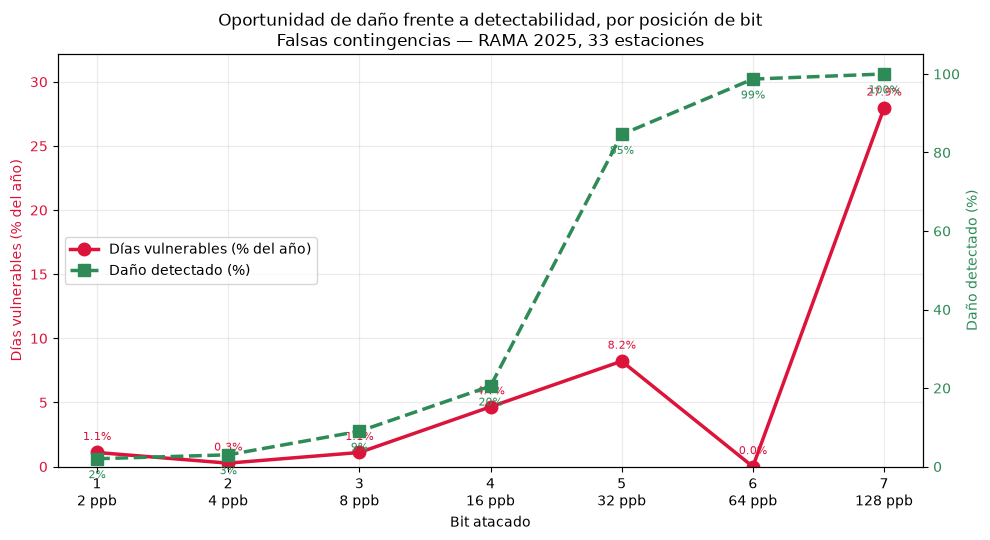

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5.5))

x = dob.bit.values

# Eje izquierdo: oportunidad de daño
c1 = 'crimson'
ax1.plot(x, dob.pct_dias, 'o-', lw=2.5, ms=9, color=c1,
         label='Días vulnerables (% del año)')
ax1.set_xlabel('Bit atacado')
ax1.set_ylabel('Días vulnerables (% del año)', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)
ax1.set_ylim(0, max(dob.pct_dias.max(), 20) * 1.15)

# Eje derecho: detección
ax2 = ax1.twinx()
c2 = 'seagreen'
ax2.plot(x, dob.pct_deteccion, 's--', lw=2.5, ms=9, color=c2,
         label='Daño detectado (%)')
ax2.set_ylabel('Daño detectado (%)', color=c2)
ax2.tick_params(axis='y', labelcolor=c2)
ax2.set_ylim(0, 105)

# Etiquetas de valor
for xi, yi in zip(x, dob.pct_dias):
    ax1.annotate(f'{yi:.1f}%', (xi, yi), textcoords='offset points',
                 xytext=(0, 9), ha='center', fontsize=8, color=c1)
for xi, yi in zip(x, dob.pct_deteccion):
    ax2.annotate(f'{yi:.0f}%', (xi, yi), textcoords='offset points',
                 xytext=(0, -14), ha='center', fontsize=8, color=c2)

ax1.set_xticks(x)
ax1.set_xticklabels([f'{b}\n{2**b} ppb' for b in x])
ax1.grid(alpha=0.25)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='center left')

ax1.set_title('Oportunidad de daño frente a detectabilidad, por posición de bit\n'
              'Falsas contingencias — RAMA 2025, 33 estaciones')

plt.tight_layout()
plt.savefig('../docs/img/doble_eje_bits.png', dpi=150)
plt.show()

In [15]:
for bit in range(1, 8):
    d = 2 ** bit
    franja = (~es_cont) & (m <= TAU_CONT) & (m > TAU_CONT - d)
    apagado = ((m >> bit) & 1) == 0
    print(f"bit {bit} (Δ={d:>3}):  en franja {franja.sum():>3}  "
          f"apagados {(franja & apagado).sum():>3}  "
          f"rango ({TAU_CONT-d}, 154]")

bit 1 (Δ=  2):  en franja   6  apagados   4  rango (152, 154]
bit 2 (Δ=  4):  en franja   7  apagados   7  rango (150, 154]
bit 3 (Δ=  8):  en franja  11  apagados   4  rango (146, 154]
bit 4 (Δ= 16):  en franja  33  apagados  17  rango (138, 154]
bit 5 (Δ= 32):  en franja  90  apagados  63  rango (122, 154]
bit 6 (Δ= 64):  en franja 256  apagados  63  rango (90, 154]
bit 7 (Δ=128):  en franja 358  apagados 295  rango (26, 154]


 bit  delta_ppb  dias_vulnerables  pct_dias_vulnerables  pct_dano_detectado  pct_dano_no_detectado
   3          8                 4                  1.10                 9.0                   1.00
   4         16                17                  4.66                20.5                   3.70
   5         32                63                 17.26                84.6                   2.66
   6         64                63                 17.26                98.7                   0.22
   7        128               295                 80.82               100.0                   0.00


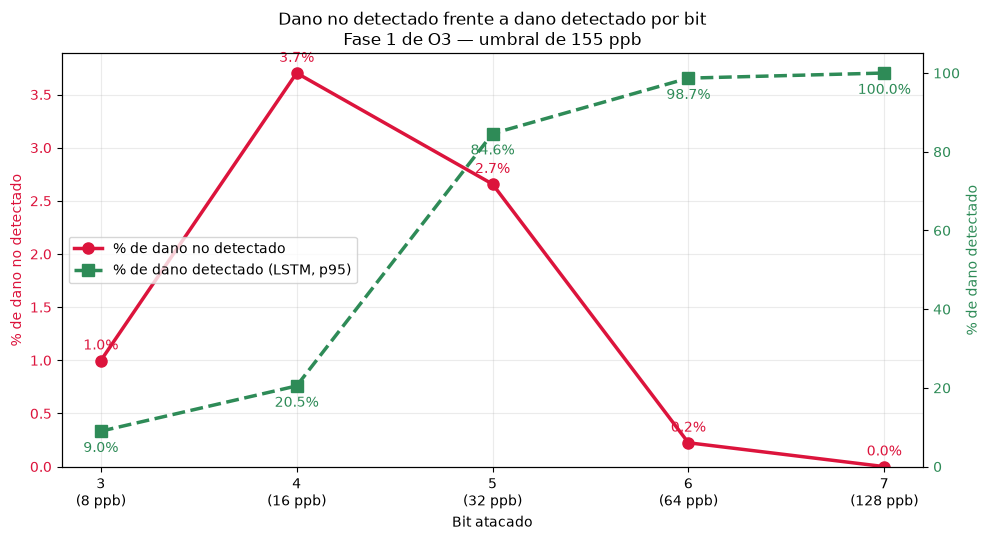

In [16]:
# Doble eje: dias vulnerables frente a dano detectado
# Vulnerabilidad: el flip real del bit crea una activacion falsa de Fase 1.
# Deteccion: recall LSTM p95 medido experimentalmente.

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().resolve()
if not (RAIZ / 'src').is_dir():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))
from src.ingest.rama import load_wide, to_long

TAU_CONTINGENCIA = 155
BITS = [3, 4, 5, 6, 7]
long_08 = to_long(load_wide(RAIZ / 'data' / 'raw' / '2025O3.xls'), 'O3')
matriz_08 = (long_08.pivot(index='timestamp', columns='station', values='value')
                  .sort_index())
max_hora_08 = matriz_08.max(axis=1, skipna=True).dropna()
max_dia_08 = max_hora_08.groupby(max_hora_08.index.date).max().astype(int)

dias = np.asarray(max_dia_08.index)
maximos = max_dia_08.to_numpy(dtype=np.int64)
dias_con_contingencia = maximos >= TAU_CONTINGENCIA

deteccion = pd.read_csv(RAIZ / 'results' / 'deteccion_lstm.csv')
deteccion = deteccion[deteccion['percentil'] == 95].set_index('bit')['recall_%']
faltantes = sorted(set(BITS) - set(deteccion.index))
if faltantes:
    raise ValueError(f'No hay recall LSTM p95 medido para bits: {faltantes}')

filas_08 = []
for bit in BITS:
    recibido = maximos ^ (1 << bit)
    vulnerable = ((~dias_con_contingencia) & (maximos < TAU_CONTINGENCIA) &
                  (recibido >= TAU_CONTINGENCIA))
    n = int(vulnerable.sum())
    filas_08.append({
        'bit': bit,
        'delta_ppb': 2 ** bit,
        'dias_vulnerables': n,
        'pct_dias_vulnerables': 100 * n / len(maximos),
        'pct_dano_detectado': float(deteccion.loc[bit]),
        'pct_dano_no_detectado': (100 * n / len(maximos)) * (1 - float(deteccion.loc[bit]) / 100),
    })

doble_eje_08 = pd.DataFrame(filas_08)
doble_eje_08.to_csv(RAIZ / 'results' / 'doble_eje_vulnerabilidad_detectabilidad.csv', index=False)
print(doble_eje_08.round(2).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 5.5))
x = doble_eje_08['bit'].to_numpy()
color_vuln, color_det = 'crimson', 'seagreen'
ax1.plot(x, doble_eje_08['pct_dano_no_detectado'], 'o-', color=color_vuln, lw=2.5, ms=8, label='% de dano no detectado')
ax1.set_xlabel('Bit atacado')
ax1.set_ylabel('% de dano no detectado', color=color_vuln)
ax1.tick_params(axis='y', labelcolor=color_vuln)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(x, doble_eje_08['pct_dano_detectado'], 's--', color=color_det, lw=2.5, ms=8, label='% de dano detectado (LSTM, p95)')
ax2.set_ylabel('% de dano detectado', color=color_det)
ax2.tick_params(axis='y', labelcolor=color_det)
ax2.set_ylim(0, 105)

for xi, yi in zip(x, doble_eje_08['pct_dano_no_detectado']):
    ax1.annotate(f'{yi:.1f}%', (xi, yi), xytext=(0, 8), textcoords='offset points', ha='center', color=color_vuln)
for xi, yi in zip(x, doble_eje_08['pct_dano_detectado']):
    ax2.annotate(f'{yi:.1f}%', (xi, yi), xytext=(0, -15), textcoords='offset points', ha='center', color=color_det)

ax1.set_xticks(x)
ax1.set_xticklabels([f'{b}\n({2**b} ppb)' for b in x])
ax1.grid(alpha=0.25)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='center left')
ax1.set_title('Dano no detectado frente a dano detectado por bit\nFase 1 de O3 — umbral de 155 ppb')
plt.tight_layout()
plt.savefig(RAIZ / 'docs' / 'img' / 'doble_eje_vulnerabilidad_detectabilidad.png', dpi=150)
plt.show()

In [17]:
# Tabla operacional evento por evento: maximo diario de la red y flip por bit.
from pathlib import Path
import pandas as pd
if 'RAIZ' not in globals():
    RAIZ = Path.cwd().resolve()
    if not (RAIZ / 'src').is_dir():
        RAIZ = RAIZ.parent
if 'matriz_08' not in globals():
    from src.ingest.rama import load_wide, to_long
    long_ev = to_long(load_wide(RAIZ / 'data' / 'raw' / '2025O3.xls'), 'O3')
    matriz_08 = long_ev.pivot(index='timestamp', columns='station', values='value').sort_index()
from src.decision.nom172 import banda_o3
TAU_FASE1, TAU_FASE2 = 155, 200
BITS_EVENTO = [3, 4, 5, 6, 7]
max_hora_ev = matriz_08.max(axis=1, skipna=True).dropna()
corte_ev = int(len(matriz_08) * 0.80)
ts_inicio_test = matriz_08.index[corte_ev]
filas_evento = []
for fecha, grupo in max_hora_ev.groupby(max_hora_ev.index.date):
    ts_max = grupo.idxmax()
    original = int(round(max_hora_ev.loc[ts_max]))
    estacion = matriz_08.loc[ts_max].idxmax()
    for bit in BITS_EVENTO:
        recibido = original ^ (1 << bit)
        falsa1 = original < TAU_FASE1 and recibido >= TAU_FASE1
        anulada1 = original >= TAU_FASE1 and recibido < TAU_FASE1
        falsa2 = original < TAU_FASE2 and recibido >= TAU_FASE2
        anulada2 = original >= TAU_FASE2 and recibido < TAU_FASE2
        filas_evento.append({'fecha': pd.Timestamp(fecha), 'timestamp_maximo': ts_max,
            'hora': int(ts_max.hour), 'estacion_maximo': estacion,
            'valor_original_ppb': original, 'bit': bit, 'delta_ppb': 2 ** bit,
            'valor_recibido_ppb': recibido, 'banda_original': int(banda_o3(original)),
            'banda_recibida': int(banda_o3(recibido)),
            'cambio_banda': int(banda_o3(original) != banda_o3(recibido)),
            'contingencia_real_fase1': int(original >= TAU_FASE1),
            'falsa_fase1': int(falsa1), 'anulada_fase1': int(anulada1),
            'cruce_fase2_instantaneo': int(falsa2),
            'anulacion_fase2_instantanea': int(anulada2),
            'en_test_lstm': bool(ts_max >= ts_inicio_test)})
tabla_eventos = pd.DataFrame(filas_evento)
tabla_eventos.to_csv(RAIZ / 'results' / 'tabla_eventos_contingencia_red.csv', index=False)
print(f'Eventos diarios: {tabla_eventos.fecha.nunique()} | filas fecha-bit: {len(tabla_eventos)}')
print(f'Inicio del test cronologico LSTM: {ts_inicio_test}')
display(tabla_eventos.groupby('bit')[['cambio_banda', 'falsa_fase1', 'anulada_fase1', 'en_test_lstm']].sum())
display(tabla_eventos[(tabla_eventos.falsa_fase1 == 1) | (tabla_eventos.anulada_fase1 == 1)][
    ['fecha', 'hora', 'estacion_maximo', 'valor_original_ppb', 'bit',
     'valor_recibido_ppb', 'falsa_fase1', 'anulada_fase1', 'en_test_lstm']
].sort_values(['fecha', 'bit']))


Eventos diarios: 365 | filas fecha-bit: 1825
Inicio del test cronologico LSTM: 2025-10-20 00:00:00


,cambio_banda,falsa_fase1,anulada_fase1,en_test_lstm
bit,,,,
3,109,4,1,73
4,89,17,1,73
5,251,63,5,73
6,365,63,0,73
7,365,295,6,73


,fecha,hora,estacion_maximo,valor_original_ppb,bit,valor_recibido_ppb,falsa_fase1,anulada_fase1,en_test_lstm
4,2025-01-01,13,UAX,112,7,240,1,0,False
9,2025-01-02,16,UAX,83,7,211,1,0,False
14,2025-01-03,16,AJU,83,7,211,1,0,False
19,2025-01-04,15,CCA,84,7,212,1,0,False
24,2025-01-05,13,LLA,77,7,205,1,0,False
...,...,...,...,...,...,...,...,...,...
1804,2025-12-27,14,GAM,94,7,222,1,0,True
1809,2025-12-28,16,CCA,96,7,224,1,0,True
1814,2025-12-29,13,AJM,69,7,197,1,0,True
1819,2025-12-30,16,BJU,48,7,176,1,0,True
